# Financial Data Analysis using R2R Process
This project simulates the SAP Record-to-Report (R2R) process using a sales dataset and Python for financial analysis and reporting.

## Import Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_palette("Set2")

## Load Dataset

In [2]:
df = pd.read_csv("train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## Data Cleaning 

In [3]:
# Convert Sales to numeric
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')

# Convert Date safely
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')

# Drop bad rows
df = df.dropna(subset=['Sales', 'Order Date'])

# Create Month & Year
df['Month'] = df['Order Date'].dt.to_period('M').astype(str)
df['Year'] = df['Order Date'].dt.year

# Create Expense & Profit
df['Expense'] = df['Sales'] * 0.7
df['Profit'] = df['Sales'] * 0.3

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Month,Year,Expense,Profit
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017-11,2017,183.37200,78.58800
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017-11,2017,512.35800,219.58200
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017-06,2017,10.23400,4.38600
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016-10,2016,670.30425,287.27325
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016-10,2016,15.65760,6.71040


## Summary

In [4]:
print("Total Sales:", df['Sales'].sum())
print("Total Expense:", df['Expense'].sum())
print("Total Profit:", df['Profit'].sum())

Total Sales: 2261536.7827
Total Expense: 1583075.7478899998
Total Profit: 678461.0348099999


## Monthly Sales 

In [6]:
monthly_sales = df.groupby('Month')['Sales'].sum()

print("Monthly Sales:\n", monthly_sales)
print("\nHighest Month:", monthly_sales.idxmax())
print("Lowest Month:", monthly_sales.idxmin())

Monthly Sales:
 Month
2015-01     14205.7070
2015-02      4519.8920
2015-03     55205.7970
2015-04     27906.8550
2015-05     23644.3030
2015-06     34322.9356
2015-07     33781.5430
2015-08     27117.5365
2015-09     81623.5268
2015-10     31453.3930
2015-11     77907.6607
2015-12     68167.0585
2016-01     18066.9576
2016-02     11951.4110
2016-03     32339.3184
2016-04     34154.4685
2016-05     29959.5305
2016-06     23599.3740
2016-07     28608.2590
2016-08     36818.3422
2016-09     63133.6060
2016-10     31011.7375
2016-11     75249.3995
2016-12     74543.6012
2017-01     18542.4910
2017-02     22978.8150
2017-03     51165.0590
2017-04     38679.7670
2017-05     56656.9080
2017-06     39724.4860
2017-07     38320.7830
2017-08     30542.2003
2017-09     69193.3909
2017-10     59583.0330
2017-11     79066.4958
2017-12     95739.1210
2018-01     43476.4740
2018-02     19920.9974
2018-03     58863.4128
2018-04     35541.9101
2018-05     43825.9822
2018-06     48190.7277
2018-07     

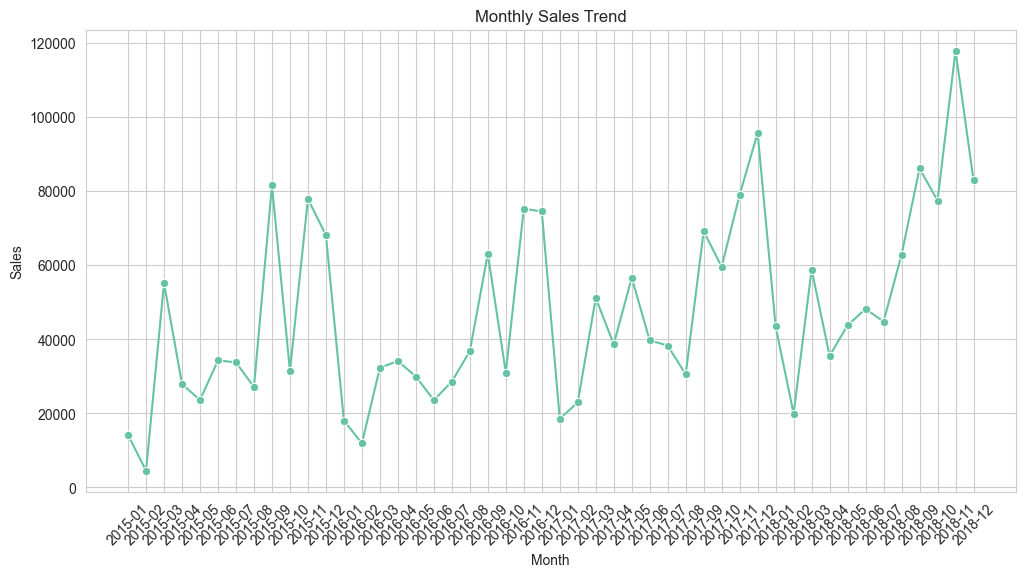

In [5]:
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_sales, x='Month', y='Sales', marker='o')

plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)

plt.savefig("monthly_sales.png")
plt.show()

## Category-wise Sales Analysis

In [7]:
category_sales = df.groupby('Category')['Sales'].sum()

print("Category Sales:\n", category_sales)
print("\nTop Category:", category_sales.idxmax())

Category Sales:
 Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64

Top Category: Technology


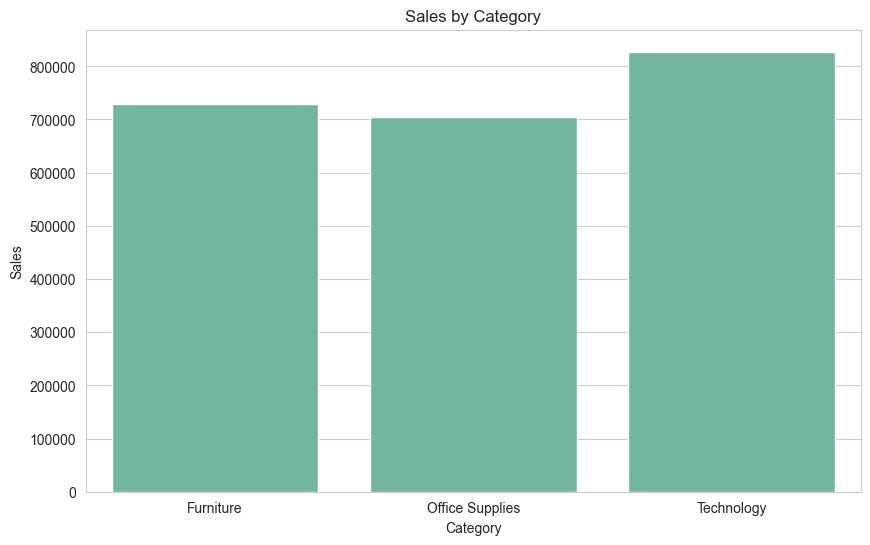

In [8]:
category_sales = category_sales.reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=category_sales, x='Category', y='Sales')

plt.title("Sales by Category")

plt.savefig("category_sales.png")
plt.show()

## Region-wise Profit Analysis

In [9]:
region_profit = df.groupby('Region')['Profit'].sum()

print("Region Profit:\n", region_profit)
print("\nBest Region:", region_profit.idxmax())

Region Profit:
 Region
Central    147794.07396
East       200855.61780
South      116745.43770
West       213065.90535
Name: Profit, dtype: float64

Best Region: West


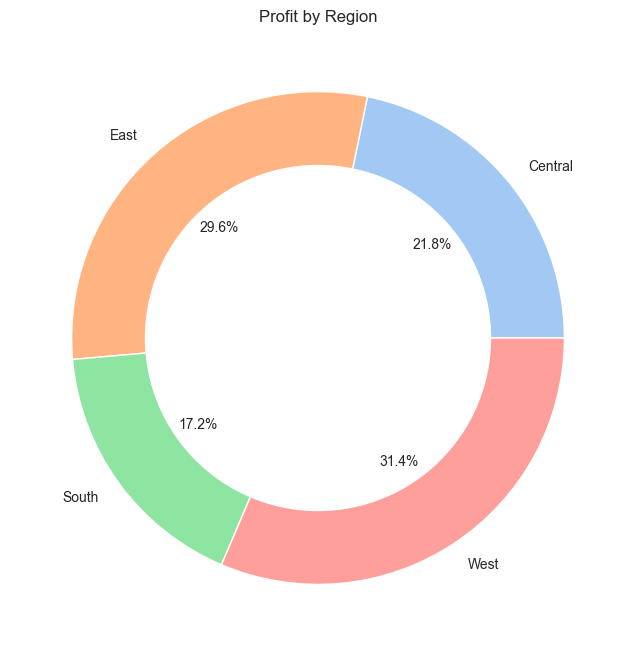

In [10]:
plt.figure(figsize=(8,8))
colors = sns.color_palette("pastel")

plt.pie(region_profit, labels=region_profit.index, autopct='%1.1f%%', colors=colors)

centre_circle = plt.Circle((0,0),0.70,fc='white')
plt.gca().add_artist(centre_circle)

plt.title("Profit by Region")

plt.savefig("region_profit.png")
plt.show()

## Top Customers Analysis

In [11]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(5)

print("Top Customers:\n", top_customers)

Top Customers:
 Customer Name
Sean Miller      25043.050
Tamara Chand     19052.218
Raymond Buch     15117.339
Tom Ashbrook     14595.620
Adrian Barton    14473.571
Name: Sales, dtype: float64


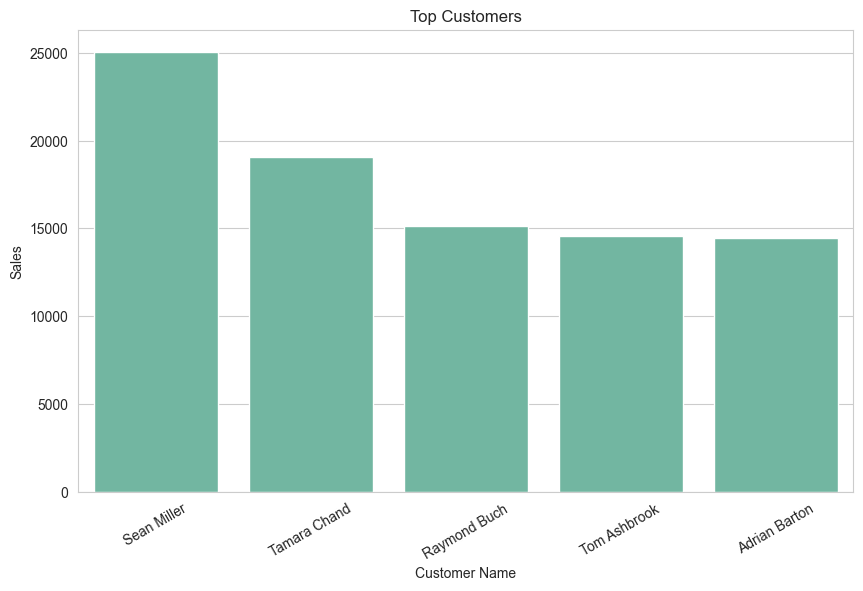

In [12]:
top_customers = top_customers.reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=top_customers, x='Customer Name', y='Sales')

plt.title("Top Customers")
plt.xticks(rotation=30)

plt.savefig("top_customers.png")
plt.show()

## Segment-wise Sales Analysis

In [13]:
segment_sales = df.groupby('Segment')['Sales'].sum()

print("Segment Sales:\n", segment_sales)
print("\nTop Segment:", segment_sales.idxmax())

Segment Sales:
 Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64

Top Segment: Consumer


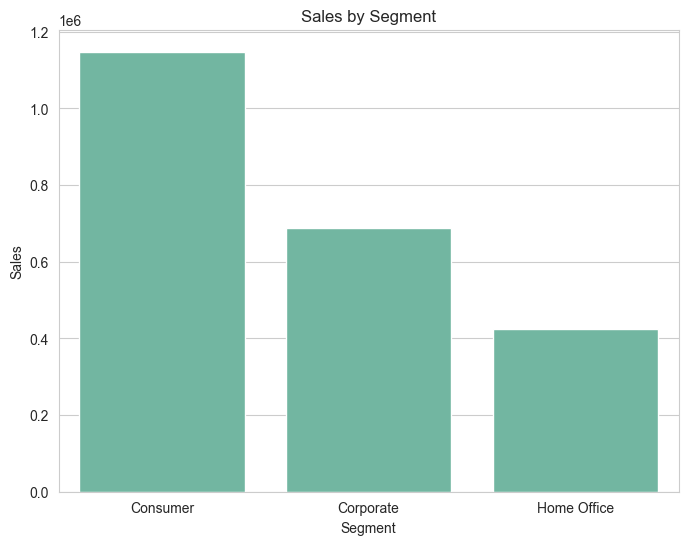

In [14]:
segment_sales = segment_sales.reset_index()

plt.figure(figsize=(8,6))
sns.barplot(data=segment_sales, x='Segment', y='Sales')

plt.title("Sales by Segment")

plt.savefig("segment_sales.png")
plt.show()

## Profit Margin Analysis

In [15]:
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100

margin = df.groupby('Category')['Profit Margin'].mean()

print("Profit Margin:\n", margin.round(2))

Profit Margin:
 Category
Furniture          30.0
Office Supplies    30.0
Technology         30.0
Name: Profit Margin, dtype: float64


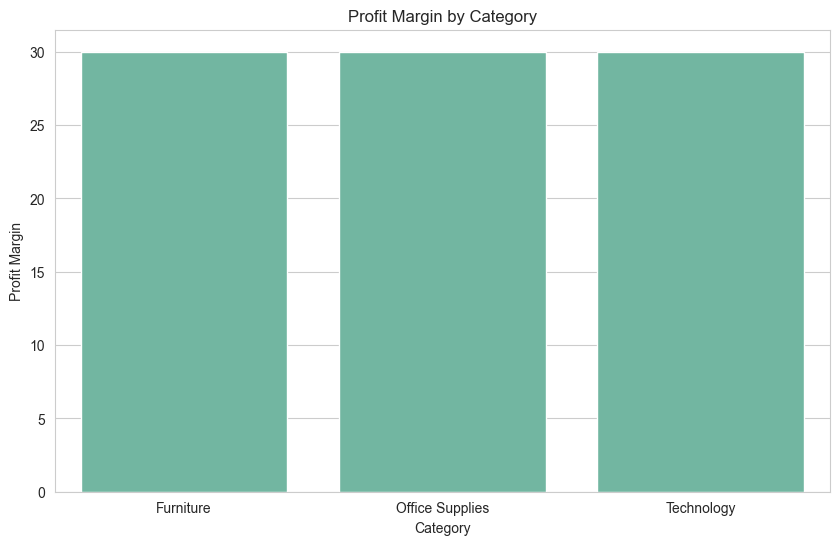

In [16]:
margin = margin.reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=margin, x='Category', y='Profit Margin')

plt.title("Profit Margin by Category")

plt.savefig("profit_margin.png")
plt.show()

## Monthly Profit Analysis

In [17]:
monthly_profit = df.groupby('Month')['Profit'].sum()

print("Monthly Profit:\n", monthly_profit)
print("\nBest Profit Month:", monthly_profit.idxmax())
print("Lowest Profit Month:", monthly_profit.idxmin())

Monthly Profit:
 Month
2015-01     4261.71210
2015-02     1355.96760
2015-03    16561.73910
2015-04     8372.05650
2015-05     7093.29090
2015-06    10296.88068
2015-07    10134.46290
2015-08     8135.26095
2015-09    24487.05804
2015-10     9436.01790
2015-11    23372.29821
2015-12    20450.11755
2016-01     5420.08728
2016-02     3585.42330
2016-03     9701.79552
2016-04    10246.34055
2016-05     8987.85915
2016-06     7079.81220
2016-07     8582.47770
2016-08    11045.50266
2016-09    18940.08180
2016-10     9303.52125
2016-11    22574.81985
2016-12    22363.08036
2017-01     5562.74730
2017-02     6893.64450
2017-03    15349.51770
2017-04    11603.93010
2017-05    16997.07240
2017-06    11917.34580
2017-07    11496.23490
2017-08     9162.66009
2017-09    20758.01727
2017-10    17874.90990
2017-11    23719.94874
2017-12    28721.73630
2018-01    13042.94220
2018-02     5976.29922
2018-03    17659.02384
2018-04    10662.57303
2018-05    13147.79466
2018-06    14457.21831
2018-07    

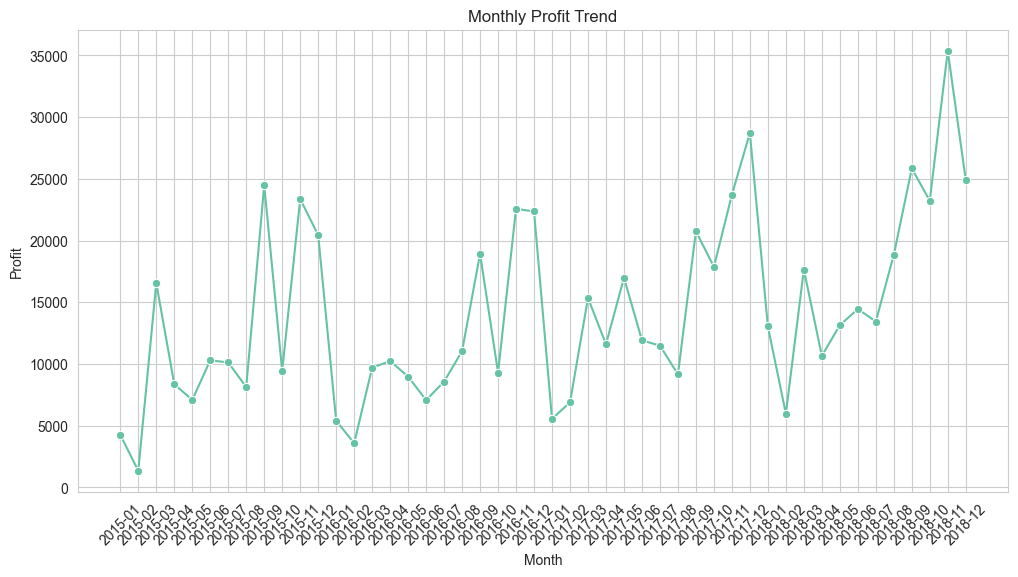

In [18]:
monthly_profit = monthly_profit.reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_profit, x='Month', y='Profit', marker='o')

plt.title("Monthly Profit Trend")
plt.xticks(rotation=45)

plt.savefig("monthly_profit.png")
plt.show()

## Sales vs Profit Analysis

In [19]:
correlation = df[['Sales','Profit']].corr()

print("Correlation between Sales and Profit:\n", correlation)

Correlation between Sales and Profit:
         Sales  Profit
Sales     1.0     1.0
Profit    1.0     1.0


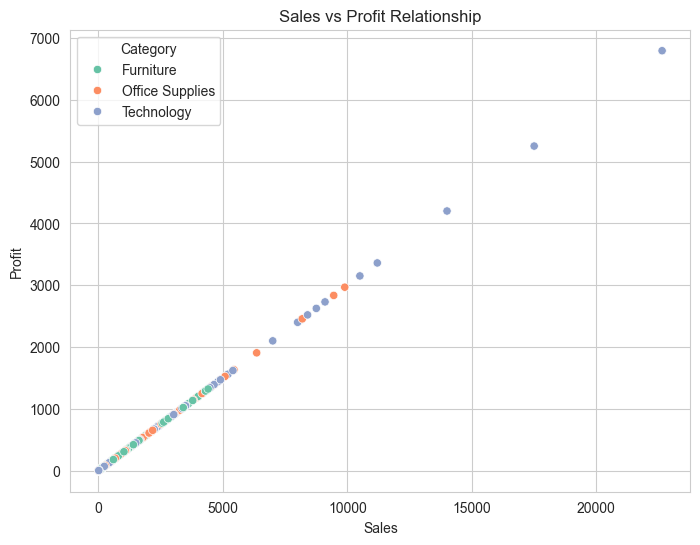

In [20]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Category')

plt.title("Sales vs Profit Relationship")

plt.savefig("sales_vs_profit.png")
plt.show()

## Top States by Sales

In [21]:
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(5)

print("Top States:\n", top_states)

Top States:
 State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Name: Sales, dtype: float64


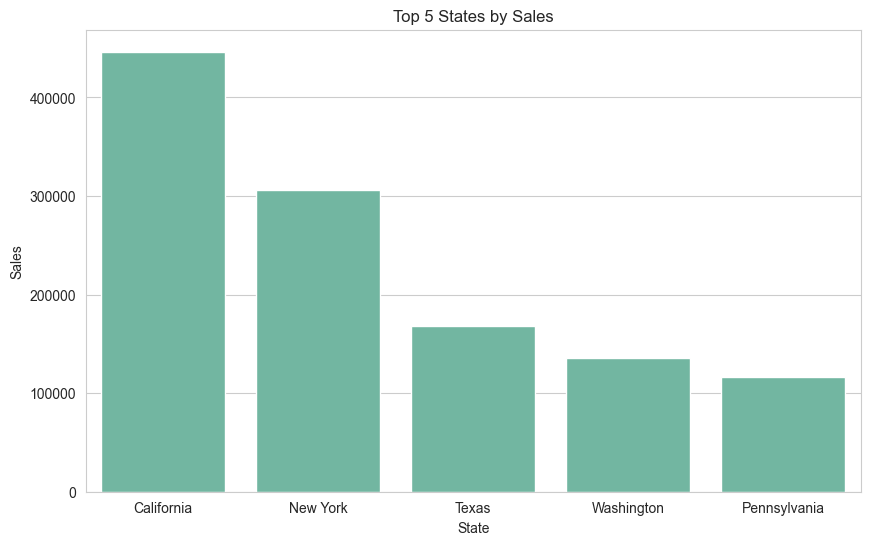

In [22]:
top_states = top_states.reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=top_states, x='State', y='Sales')

plt.title("Top 5 States by Sales")

plt.savefig("top_states.png")
plt.show()

## Sales Distribution Analysis

In [23]:
print("Minimum Sales:", df['Sales'].min())
print("Maximum Sales:", df['Sales'].max())
print("Average Sales:", round(df['Sales'].mean(), 2))

Minimum Sales: 0.444
Maximum Sales: 22638.48
Average Sales: 230.77


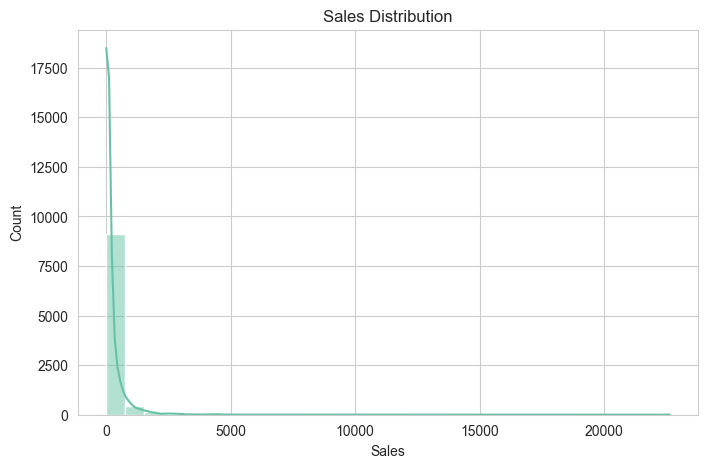

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=30, kde=True)

plt.title("Sales Distribution")

plt.savefig("sales_distribution.png")
plt.show()

## Correlation Heatmap

In [26]:
import numpy as np

df['Expense'] = df['Sales'] * np.random.uniform(0.5, 0.9, len(df))
df['Profit'] = df['Sales'] - df['Expense']

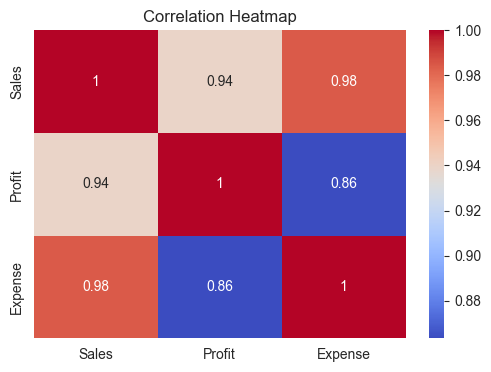

In [27]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Sales','Profit','Expense']].corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

## Shipping Delay Analysis

In [28]:
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True, errors='coerce')

df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days

print("Average Delivery Time:", round(df['Delivery Days'].mean(),2))
print("Max Delivery Time:", df['Delivery Days'].max())

Average Delivery Time: 3.96
Max Delivery Time: 7


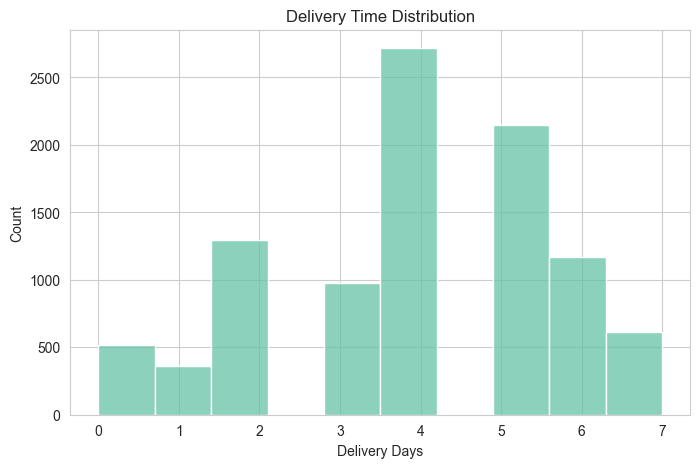

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(df['Delivery Days'], bins=10)

plt.title("Delivery Time Distribution")

plt.savefig("delivery_time.png")
plt.show()

## Sub-Category Analysis

In [30]:
subcat = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

print("Top Sub-Categories:\n", subcat.head(5))

Top Sub-Categories:
 Sub-Category
Phones     327782.448
Chairs     322822.731
Storage    219343.392
Tables     202810.628
Binders    200028.785
Name: Sales, dtype: float64


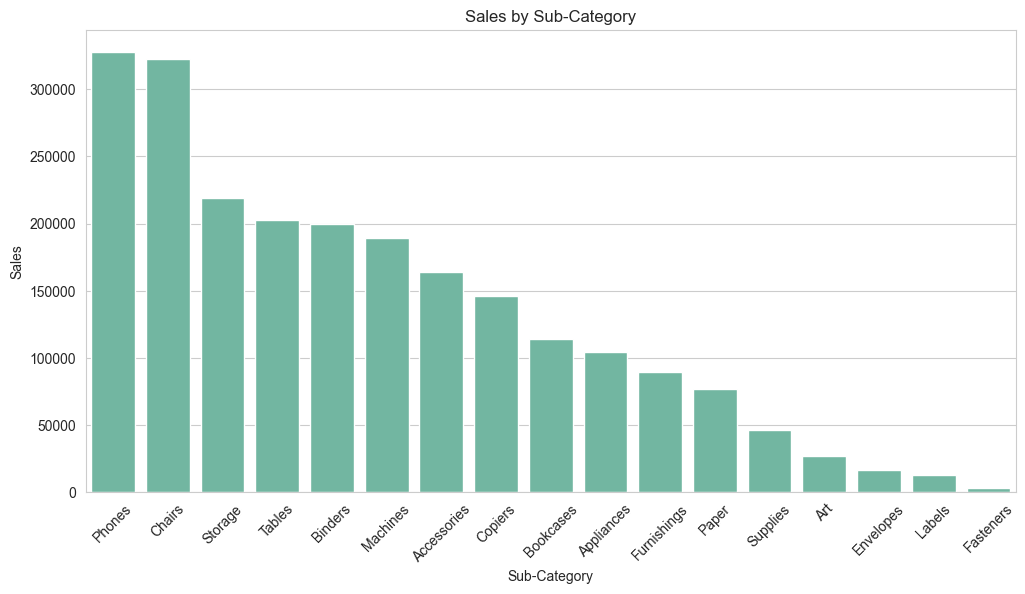

In [32]:
subcat = subcat.reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=subcat, x='Sub-Category', y='Sales')

plt.title("Sales by Sub-Category")
plt.xticks(rotation=45)

plt.savefig("sub_category.png")
plt.show()

## City-wise Sales

In [31]:
top_cities = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(5)

print("Top Cities:\n", top_cities)

Top Cities:
 City
New York City    252462.547
Los Angeles      173420.181
Seattle          116106.322
San Francisco    109041.120
Philadelphia     108841.749
Name: Sales, dtype: float64


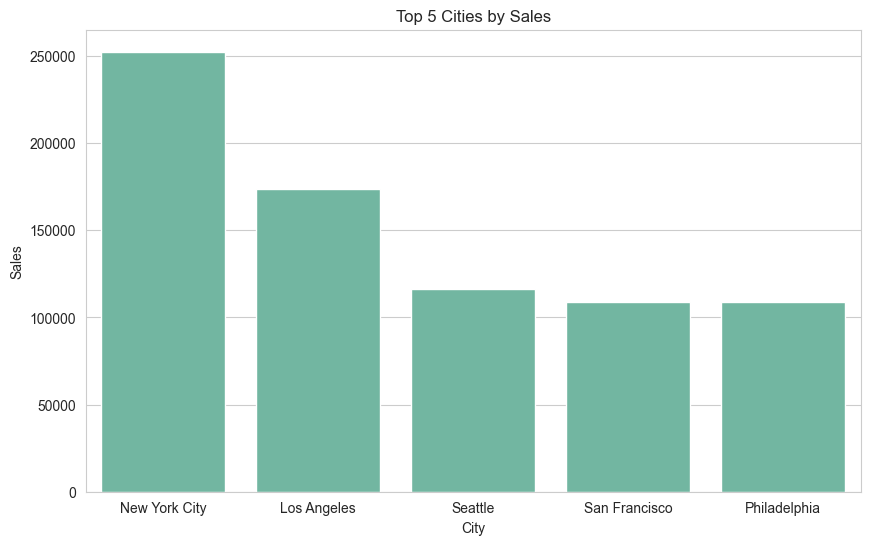

In [33]:
top_cities = top_cities.head(5).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=top_cities, x='City', y='Sales')

plt.title("Top 5 Cities by Sales")

plt.savefig("city_sales.png")
plt.show()